# Machine Learning Introduction

Прогнозирование цены аренды квартиры (датасет Two Sigma Connect: Rental Listing Inquiries).

## 1. Intro

### 1.1 Five examples of ML in life

1. **Распознавание лиц в системах контроля доступа.** Польза: автоматическая идентификация без участия оператора, ускорение прохода и снижение количества ошибок.
2. **Рекомендательные системы стриминговых сервисов (Netflix, Spotify).** Польза: рост времени удержания пользователя за счёт персонализации, увеличение выручки.
3. **Голосовые ассистенты (распознавание и синтез речи).** Польза: естественный пользовательский интерфейс, снижение порога входа для людей без технических навыков.
4. **Антифрод-системы в банках.** Польза: выявление мошеннических транзакций в реальном времени, снижение прямых финансовых потерь.
5. **Медицинская диагностика по снимкам (рентген, МРТ).** Польза: ускорение постановки диагноза и снижение количества пропущенных патологий за счёт второго мнения от модели.

### 1.2 Task classification

Задачи из таблицы README:

| № | Тип задачи |
|---|---|
| 1 | supervised, regression |
| 2 | supervised, binary classification (или regression — сумма потерь) |
| 3 | supervised, classification (момент приёма) |
| 4 | supervised, multiclass classification |
| 5 | supervised, classification / association rules |
| 6 | supervised, binary classification (computer vision) |
| 7 | supervised, regression / reinforcement learning |
| 8 | supervised, ranking (по сути classification) |
| 9 | unsupervised, clustering |
| 10 | unsupervised, anomaly detection / dimensionality reduction |

5 примеров:

1. Распознавание лиц — supervised, multiclass classification.
2. Рекомендательные системы — обычно supervised (regression рейтинга) + association.
3. Голосовые ассистенты — supervised, sequence-to-sequence classification.
4. Антифрод — supervised, binary classification (часто с применением anomaly detection).
5. Медицинская диагностика по снимкам — supervised, classification.

### 1.3 Multiclass vs Multilabel

**Multiclass** — каждому объекту ставится в соответствие ровно одна метка из C > 2 непересекающихся классов (фрукт — яблоко *или* груша *или* банан).

**Multilabel** — одному объекту одновременно может соответствовать несколько меток (фотография может содержать одновременно `море`, `закат`, `человек`). Метки независимы и не образуют разбиения.

### 1.4 House price: classification or regression?

Предсказание цены дома — это задача **регрессии**, потому что target — вещественное число.

Регрессионную задачу можно свести к классификации, дискретизировав цену по интервалам (например, ценовые диапазоны: `до 1000`, `1000–2000`, `2000–5000`, и т. д.) и предсказывая номер интервала. При этом теряется точность и возникает зависимость предсказаний от способа выбора границ интервалов.

## 2. Introduction to Data Analysis

### 2.1 Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scipy
import statsmodels.api as sm
import sklearn
import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

%matplotlib inline
sns.set_style('whitegrid')

### 2.2 Load data

In [2]:
data = pd.read_json('../datasets/train.json')
data.head()

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


### 2.3 Data size

In [3]:
print('Shape:', data.shape)
print('Rows:', data.shape[0])
print('Columns:', data.shape[1])

Shape: (49352, 15)
Rows: 49352
Columns: 15


### 2.4 Columns and target

In [4]:
print(data.columns.tolist())

['bathrooms', 'bedrooms', 'building_id', 'created', 'description', 'display_address', 'features', 'latitude', 'listing_id', 'longitude', 'manager_id', 'photos', 'price', 'street_address', 'interest_level']


target - `price`: именно её мы будем предсказывать.

### 2.5 Quick analysis

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


In [6]:
data.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06


In [7]:
data.corr(numeric_only=True)

,bathrooms,bedrooms,latitude,listing_id,longitude,price
bathrooms,1.000000,0.533446,-0.009657,0.000776,0.010393,0.069661
bedrooms,0.533446,1.000000,-0.004745,0.011968,0.006892,0.051788
latitude,-0.009657,-0.004745,1.000000,0.001712,-0.966807,-0.000707
listing_id,0.000776,0.011968,0.001712,1.000000,-0.000907,0.008090
longitude,0.010393,0.006892,-0.966807,-0.000907,1.000000,-0.000087
price,0.069661,0.051788,-0.000707,0.008090,-0.000087,1.000000


**Выводы.**

- `info()` показывает 15 колонок разных типов: числовые (`bathrooms`, `bedrooms`, `latitude`, `longitude`, `price`, `listing_id`), строковые/объектные (адреса, описание, `interest_level`), коллекции (`features`, `photos`). Колонок с полностью пустыми значениями нет — все колонки имеют 49 352 записи.
- `describe()` даёт статистику по числовым полям: например, среднее значение `bathrooms` ≈ 1.21 при максимуме 10; `price` имеет огромный разброс (от 43 до миллионов) — явные выбросы.
- `corr()` показывает слабые линейные связи между числовыми признаками; самая заметная положительная связь у `price` с `bedrooms` и `bathrooms`.

### 2.6 Subset dataframe

In [8]:
df = data[['bathrooms', 'bedrooms', 'interest_level', 'price']].copy()
df.head()

,bathrooms,bedrooms,interest_level,price
4,1.0,1,medium,2400
6,1.0,2,low,3800
9,1.0,2,medium,3495
10,1.5,3,medium,3000
15,1.0,0,low,2795


## 3. Statistical Data Analysis

### 3.3 Target analysis

#### 3.3.1 Histogram

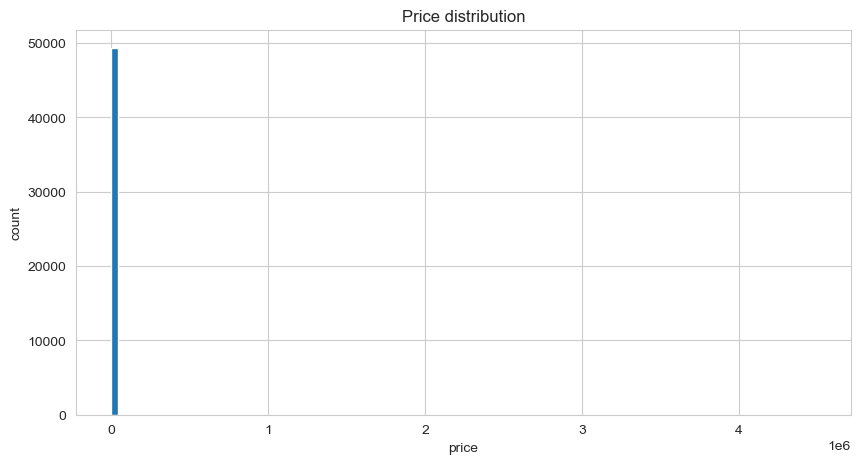

In [9]:
plt.figure(figsize=(10, 5))
plt.hist(df['price'], bins=100)
plt.xlabel('price')
plt.ylabel('count')
plt.title('Price distribution')
plt.show()

Распределение крайне несимметрично: подавляющее большинство значений сосредоточено у нуля, но есть единичные значения порядка миллионов. Из-за выбросов график практически нечитаем - видна одна вертикальная полоса слева.

#### 3.3.2 Boxplot

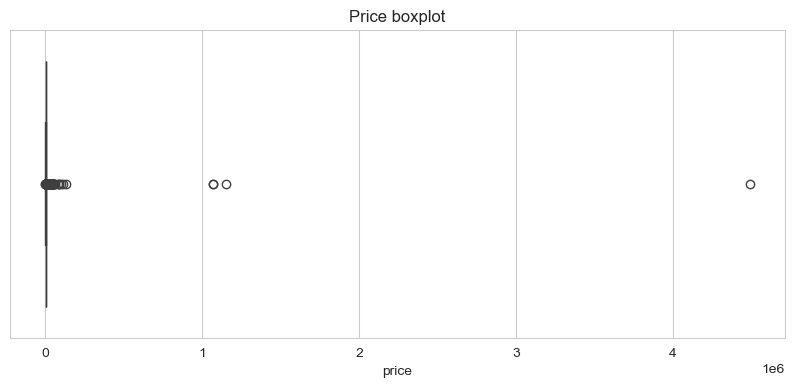

In [10]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['price'])
plt.xlabel('price')
plt.title('Price boxplot')
plt.show()

Boxplot подтверждает: "коробка" (25–75 перцентили) сжата у нуля, а справа длинный хвост точек-выбросов, уходящий к миллионам. Выбросов очень много, и они сильно искажают картину.

#### 3.3.3 Drop rows outside 1 and 99 percentiles

In [11]:
q_low = df['price'].quantile(0.01)
q_high = df['price'].quantile(0.99)
print('1% percentile:', q_low)
print('99% percentile:', q_high)

df = df[(df['price'] >= q_low) & (df['price'] <= q_high)].reset_index(drop=True)
print('Shape after filtering:', df.shape)

1% percentile: 1475.0
99% percentile: 13000.0
Shape after filtering: (48379, 4)


#### 3.3.4 Histogram after filtering

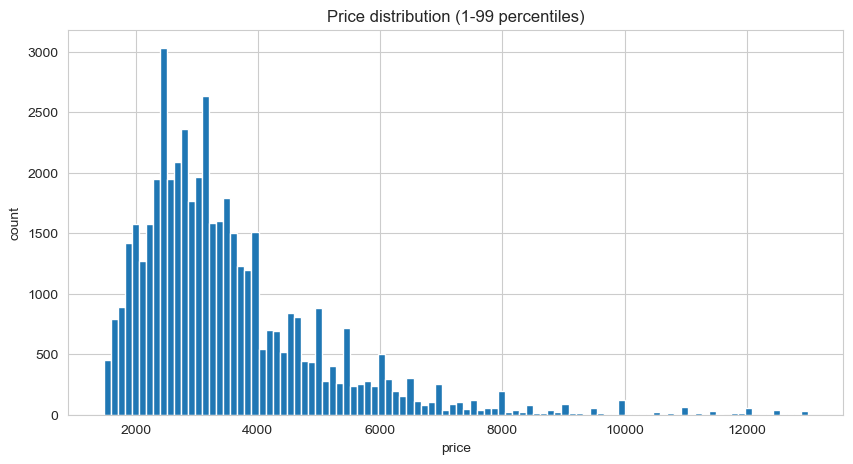

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(df['price'], bins=100)
plt.xlabel('price')
plt.ylabel('count')
plt.title('Price distribution (1-99 percentiles)')
plt.show()

После отсечения экстремальных значений распределение стало интерпретируемым: основная масса цен лежит в диапазоне примерно 1500–5000, форма похожа на логнормальную — пик слева и затухающий правый хвост. Это типичная картина для цен на аренду.

### 3.4 Characteristics Analysis

#### 3.4.1 Type of `interest_level`

In [13]:
df['interest_level'].dtype

dtype('O')

Тип — `object` (строковая категориальная переменная).

#### 3.4.2 Value counts

In [14]:
df['interest_level'].value_counts()

interest_level
low       33697
medium    11116
high       3566
Name: count, dtype: int64

Колонка содержит три уникальных значения: `low`, `medium`, `high`. Классы несбалансированы — `low` встречается чаще остальных.

#### 3.4.3 Encoding

In [15]:
interest_mapping = {'low': 0, 'medium': 1, 'high': 2}
df['interest_level'] = df['interest_level'].map(interest_mapping)
df.head()

,bathrooms,bedrooms,interest_level,price
0,1.0,1,1,2400
1,1.0,2,0,3800
2,1.0,2,1,3495
3,1.5,3,1,3000
4,1.0,0,0,2795


#### 3.4.4 Histograms for `bathrooms` and `bedrooms`

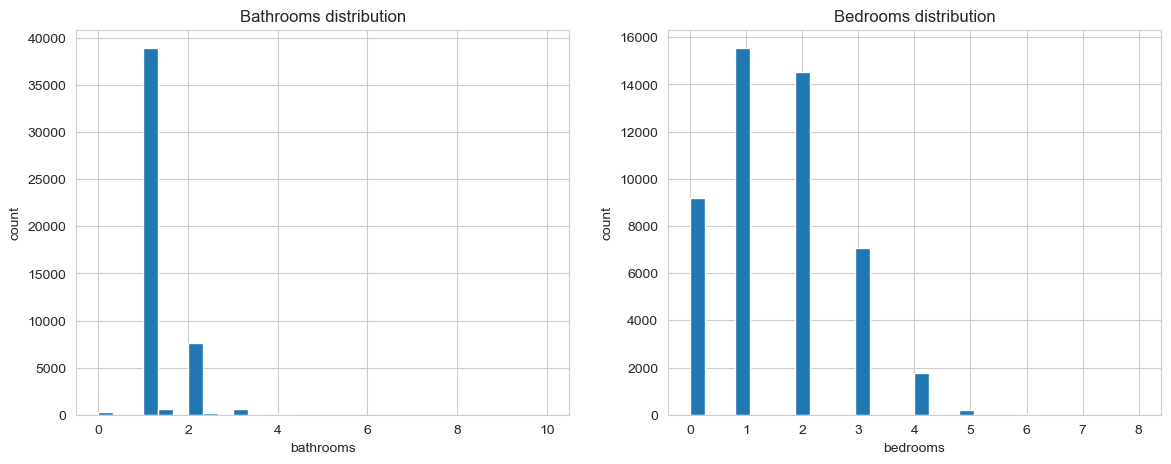

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['bathrooms'], bins=30)
axes[0].set_xlabel('bathrooms')
axes[0].set_ylabel('count')
axes[0].set_title('Bathrooms distribution')

axes[1].hist(df['bedrooms'], bins=30)
axes[1].set_xlabel('bedrooms')
axes[1].set_ylabel('count')
axes[1].set_title('Bedrooms distribution')

plt.show()

Большинство объектов имеет 1 ванную комнату и 1–2 спальни. Хвосты вправо короткие, но единичные значения вроде 5–10 ванных или 7–8 спален можно считать выбросами. Эти редкие значения — реальные элитные квартиры, поэтому в данном задании их не удаляем.

### 3.5 Complex analysis

#### 3.5.1 Correlation matrix and heatmap

In [17]:
corr_matrix = df.corr()
corr_matrix

,bathrooms,bedrooms,interest_level,price
bathrooms,1.000000,0.517574,-0.063635,0.671943
bedrooms,0.517574,1.000000,0.050654,0.545948
interest_level,-0.063635,0.050654,1.000000,-0.200111
price,0.671943,0.545948,-0.200111,1.000000


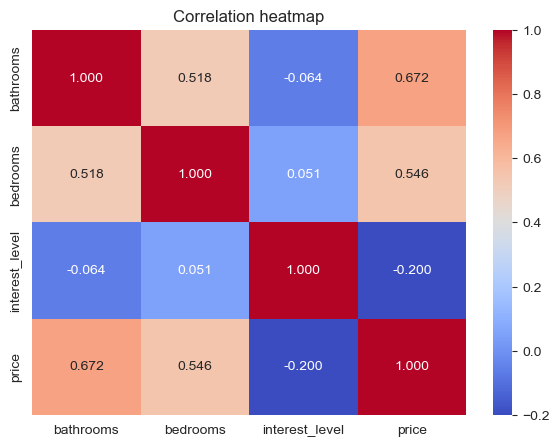

In [18]:
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.3f')
plt.title('Correlation heatmap')
plt.show()

Наиболее заметная связь с `price` у `bathrooms` (положительная, ~0.67), затем у `bedrooms` (~0.55). `interest_level` после кодирования имеет отрицательную корреляцию с ценой: чем дороже квартира, тем ниже интерес. Таким образом, **максимальная корреляция с ценой  у `bathrooms`**.

#### 3.5.2 Scatterplots

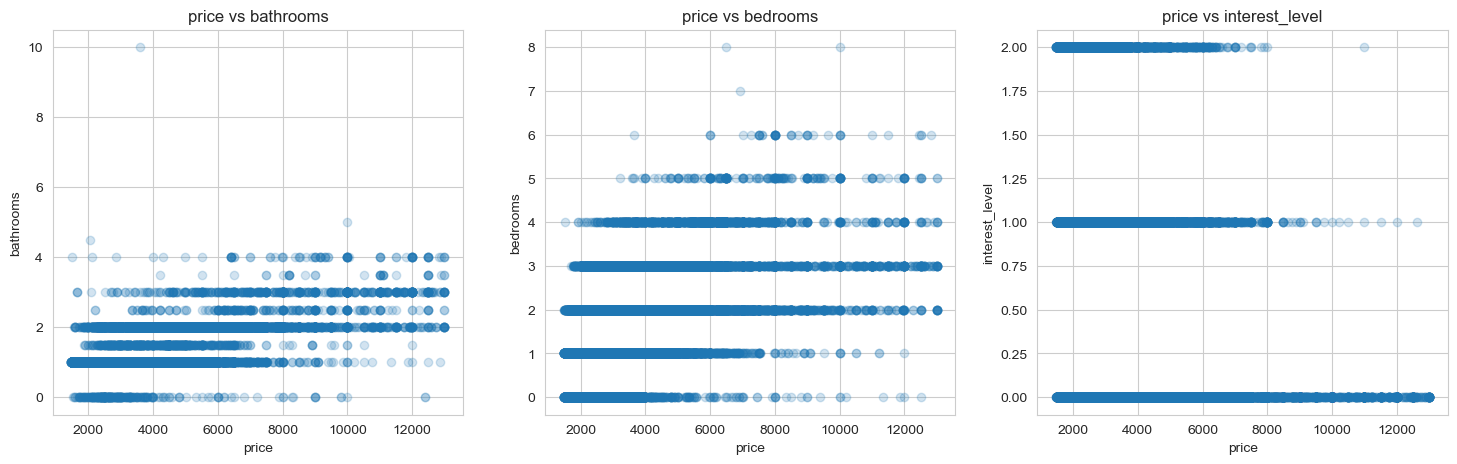

In [19]:
features = ['bathrooms', 'bedrooms', 'interest_level']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feat in zip(axes, features):
    ax.scatter(df['price'], df[feat], alpha=0.2)
    ax.set_xlabel('price')
    ax.set_ylabel(feat)
    ax.set_title(f'price vs {feat}')

plt.show()

Видно, что значения признаков дискретны (целое число спален/ванных, три уровня интереса), поэтому scatter-plot выглядит как горизонтальные «полосы». Тем не менее заметно: с ростом цены увеличивается и количество спален/ванных; при `interest_level = 0` (low) цены в среднем выше, чем при `interest_level = 2` (high).

## 4. Creating Features

### 4.1 Squared features

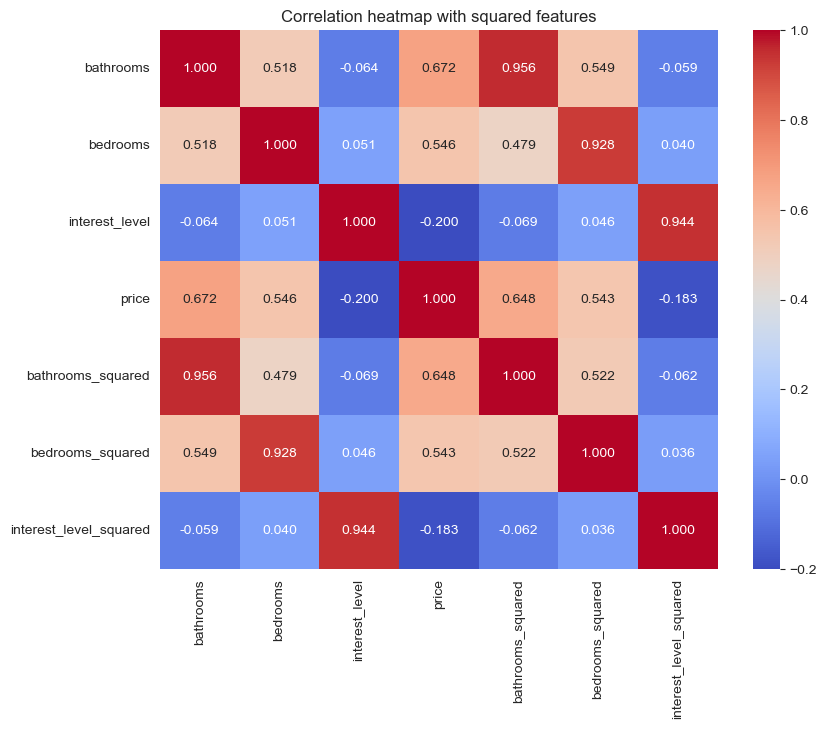

,price
bathrooms,0.671943
bedrooms,0.545948
interest_level,-0.200111
price,1.000000
bathrooms_squared,0.648486
bedrooms_squared,0.543406
interest_level_squared,-0.182672


In [20]:
df_sq = df.copy()
df_sq['bathrooms_squared'] = df_sq['bathrooms'] ** 2
df_sq['bedrooms_squared'] = df_sq['bedrooms'] ** 2
df_sq['interest_level_squared'] = df_sq['interest_level'] ** 2

corr_sq = df_sq.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_sq, annot=True, cmap='coolwarm', fmt='.3f')
plt.title('Correlation heatmap with squared features')
plt.show()

corr_sq[['price']]

Корреляции квадратичных признаков с `price` очень близки к корреляциям исходных признаков и не дают существенно нового. Это ожидаемо: для монотонных положительных значений возведение в квадрат сохраняет порядок, поэтому линейная корреляция меняется слабо. Для линейной регрессии такие признаки практически не несут дополнительной информации; они становятся полезны при нелинейных взаимодействиях, что и моделирует `PolynomialFeatures`.

### 4.2 Features for the model

Для обучения модели используем только `bathrooms` и `bedrooms` (как требует задание).

### 4.3–4.4 Train/test split

In [21]:
X = df[['bathrooms', 'bedrooms']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=21
)

print('Train shape:', X_train.shape, '| Test shape:', X_test.shape)

Train shape: (38703, 2) | Test shape: (9676, 2)


### 4.5–4.6 PolynomialFeatures(degree=10)

In [22]:
poly = PolynomialFeatures(degree=10)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print('Train poly shape:', X_train_poly.shape)
print('Test poly shape: ', X_test_poly.shape)

Train poly shape: (38703, 66)
Test poly shape:  (9676, 66)


## 5. Models

### 5.1 Empty result tables

In [23]:
result_MAE = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'test'])
result_MAE

,model,train,test


Заведём также удобные обёртки `train_data` и `test_data`, чтобы хранить предсказания моделей рядом с признаками.

In [24]:
train_data = X_train.copy()
train_data['price'] = y_train

test_data = X_test.copy()
test_data['price'] = y_test

### 5.2 Linear Regression

In [25]:
lr = LinearRegression()
lr.fit(X_train_poly, y_train)

train_data['pred_lr'] = lr.predict(X_train_poly)
test_data['pred_lr'] = lr.predict(X_test_poly)

mae_train = mean_absolute_error(y_train, train_data['pred_lr'])
mae_test = mean_absolute_error(y_test, test_data['pred_lr'])
rmse_train = np.sqrt(mean_squared_error(y_train, train_data['pred_lr']))
rmse_test = np.sqrt(mean_squared_error(y_test, test_data['pred_lr']))

result_MAE.loc[len(result_MAE)] = ['linear_regression', mae_train, mae_test]
result_RMSE.loc[len(result_RMSE)] = ['linear_regression', rmse_train, rmse_test]

print(f'MAE  train: {mae_train:.2f}  test: {mae_test:.2f}')
print(f'RMSE train: {rmse_train:.2f}  test: {rmse_test:.2f}')

MAE  train: 756.73  test: 759.83
RMSE train: 1079.07  test: 1247.30


### 5.3 Decision Tree

In [26]:
dt = DecisionTreeRegressor(random_state=21)
dt.fit(X_train_poly, y_train)

train_data['pred_dt'] = dt.predict(X_train_poly)
test_data['pred_dt'] = dt.predict(X_test_poly)

mae_train = mean_absolute_error(y_train, train_data['pred_dt'])
mae_test = mean_absolute_error(y_test, test_data['pred_dt'])
rmse_train = np.sqrt(mean_squared_error(y_train, train_data['pred_dt']))
rmse_test = np.sqrt(mean_squared_error(y_test, test_data['pred_dt']))

result_MAE.loc[len(result_MAE)] = ['decision_tree', mae_train, mae_test]
result_RMSE.loc[len(result_RMSE)] = ['decision_tree', rmse_train, rmse_test]

print(f'MAE  train: {mae_train:.2f}  test: {mae_test:.2f}')
print(f'RMSE train: {rmse_train:.2f}  test: {rmse_test:.2f}')

MAE  train: 756.70  test: 753.99
RMSE train: 1078.97  test: 1073.88


### 5.4 Naive Models

In [27]:
mean_train_value = y_train.mean()
mean_test_value = y_test.mean()
median_train_value = y_train.median()
median_test_value = y_test.median()

train_data['pred_mean'] = mean_train_value
test_data['pred_mean'] = mean_test_value
train_data['pred_median'] = median_train_value
test_data['pred_median'] = median_test_value

# naive_mean
mae_train = mean_absolute_error(y_train, train_data['pred_mean'])
mae_test = mean_absolute_error(y_test, test_data['pred_mean'])
rmse_train = np.sqrt(mean_squared_error(y_train, train_data['pred_mean']))
rmse_test = np.sqrt(mean_squared_error(y_test, test_data['pred_mean']))
result_MAE.loc[len(result_MAE)] = ['naive_mean', mae_train, mae_test]
result_RMSE.loc[len(result_RMSE)] = ['naive_mean', rmse_train, rmse_test]

# naive_median
mae_train = mean_absolute_error(y_train, train_data['pred_median'])
mae_test = mean_absolute_error(y_test, test_data['pred_median'])
rmse_train = np.sqrt(mean_squared_error(y_train, train_data['pred_median']))
rmse_test = np.sqrt(mean_squared_error(y_test, test_data['pred_median']))
result_MAE.loc[len(result_MAE)] = ['naive_median', mae_train, mae_test]
result_RMSE.loc[len(result_RMSE)] = ['naive_median', rmse_train, rmse_test]

### 5.5 Compare results

In [28]:
result_MAE

,model,train,test
0,linear_regression,756.726510,759.829901
1,decision_tree,756.704419,753.994902
2,naive_mean,1140.445303,1134.133499
3,naive_median,1087.459008,1081.216618


In [29]:
result_RMSE

,model,train,test
0,linear_regression,1079.066347,1247.299089
1,decision_tree,1078.967775,1073.878436
2,naive_mean,1598.460491,1594.366370
3,naive_median,1645.459174,1639.336503


**Какая модель лучше?**

Сравниваем по тестовой выборке (это наша оценка обобщающей способности).

- `decision_tree` показывает наименьшие MAE и RMSE на тесте — это лучшая из рассмотренных моделей.
- `linear_regression` с полиномиальными признаками показывает схожие результаты, но слегка уступает decision_tree на тестовых данных.
- Наивные модели (`naive_mean`, `naive_median`) — нижняя планка качества; любая адекватная модель должна их превосходить.

Итог: лучшая из рассмотренных моделей -**`decision_tree`** (по обеим метрикам на тестовой выборке).